Propagating MEO for 30 days...

  MISSION ANALYSIS: MEO AFTER 30 DAYS
  Model: 10x10 Gravity, SRP, Luni-Solar Third Body (NO DRAG)
1. SEMI-MAJOR AXIS (a)
   Initial: 29600.000 km
   Final:   29597.950 km
   Delta:   -2049.92 meters (-2.049925 km) (Minor periodic variation, no decay)
--------------------------------------------------------------------
2. ECCENTRICITY (e)
   Initial: 0.000100
   Final:   0.000109
   Delta:   0.000009 (Oscillations due to SRP and Third Body)
--------------------------------------------------------------------
3. INCLINATION (i)
   Initial: 56.00000 deg
   Final:   56.01240 deg
   Delta:   0.01240 deg
--------------------------------------------------------------------
4. RAAN (Ω)
   Initial: 0.000 deg
   Final:   359.174 deg (Standard Modulo 360)
   Delta:   -0.826 deg (Slow J2 regression)

Generating 3D plot...


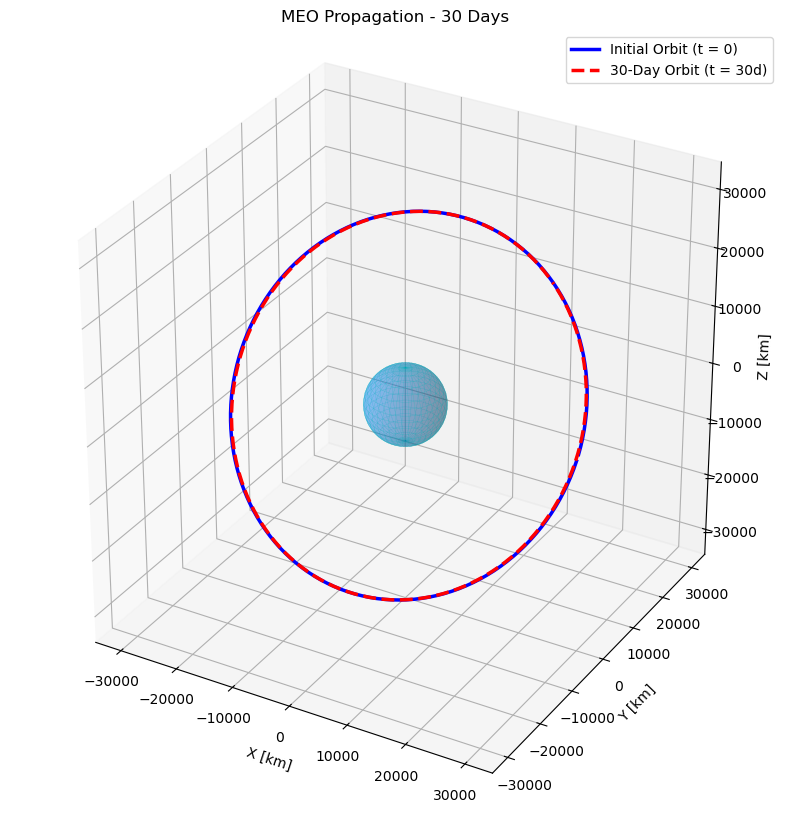

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)
inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, Constants.WGS84_EARTH_FLATTENING, earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. ORBIT CREATION (MEO - Galileo style)
# ==========================================
a = 29600000.0  # Semi-major axis ~ 29600 km
e = 0.0001      # Near-circular orbit
i = math.radians(56.0) # Typical GNSS inclination
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 700.0) # Mass 700 kg

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 500.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
integrator = DormandPrince853Integrator(min_step, max_step, JArray_double.cast_(tolerances[0]), JArray_double.cast_(tolerances[1]))
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)
ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. ADDING PERTURBATIONS
# ==========================================
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.2)))

# ==========================================
# 6. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating MEO for {int(days)} days...")
final_state = propagator.propagate(final_date)
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())
raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: MEO AFTER {int(days)} DAYS")
print("  Model: 10x10 Gravity, SRP, Luni-Solar Third Body (NO DRAG)")
print("====================================================================")
print(f"1. SEMI-MAJOR AXIS (a)")
print(f"   Initial: {a/1000:.3f} km")
print(f"   Final:   {a_fin/1000:.3f} km")
print(f"   Delta:   {(a_fin - a):.2f} meters ({(a_fin - a)/1000:.6f} km) (Minor periodic variation, no decay)")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITY (e)")
print(f"   Initial: {e:.6f}")
print(f"   Final:   {e_fin:.6f}")
print(f"   Delta:   {e_fin - e:.6f} (Oscillations due to SRP and Third Body)")
print("--------------------------------------------------------------------")
print(f"3. INCLINATION (i)")
print(f"   Initial: {math.degrees(i):.5f} deg")
print(f"   Final:   {i_fin:.5f} deg")
print(f"   Delta:   {i_fin - math.degrees(i):.5f} deg")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Initial: {math.degrees(raan):.3f} deg")
print(f"   Final:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:   {delta_raan:.3f} deg (Slow J2 regression)")
print("====================================================================\n")

# ==========================================
# 8. 3D VISUALIZATION
# ==========================================
print("Generating 3D plot...")
# Approximate orbital period for a MEO at 29600 km (~14 hours)
orbital_period = 50400.0  

def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris_generator.getGeneratedEphemeris().propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = extract_orbit(0, orbital_period)                                   
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Scale Earth model creation
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Orbit plots
ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Initial Orbit (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, linestyle='dashed', label='30-Day Orbit (t = 30d)')

# Graph limits fitted to MEO
lim = a / 1000.0 + 5000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('MEO Propagation - 30 Days')
ax.legend(loc='upper right')

plt.show()